# ClinVar Variant Pathogenicity Classifier

Predicting whether genomic variants are pathogenic or benign
using machine learning on 3.4 million ClinVar records.

**Key methodological decisions:**
- ReviewStatus used as sample weights, not a feature
- PhenotypeList excluded to avoid data leakage
- Only features available from sequencing used for prediction

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

## 1. Load data

ClinVar variant_summary.txt contains 8.9M genomic variants
with clinical significance annotations from laboratories worldwide.

In [2]:
df_full = pd.read_csv('../data/variant_summary.txt', sep='\t', low_memory=False)
print(f"Loaded: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")

Loaded: 8,907,730 rows, 43 columns


## 2. Select columns and clean data

We select only columns relevant to our prediction task.
PhenotypeList is excluded — for a novel variant, no disease
associations exist yet, making this feature unavailable at
prediction time (data leakage).

In [3]:
cols_needed = [
    'Type', 'GeneSymbol', 'ClinicalSignificance',
    'Chromosome', 'Start', 'ReviewStatus', 'Origin'
]
df_small = df_full[cols_needed].copy()
print(f"Selected {len(cols_needed)} columns")

Selected 7 columns


In [4]:
label_map = {
    'Pathogenic': 'Pathogenic',
    'Likely pathogenic': 'Pathogenic',
    'Pathogenic/Likely pathogenic': 'Pathogenic',
    'Benign': 'Benign',
    'Likely benign': 'Benign',
    'Benign/Likely benign': 'Benign',
}
df_small['label'] = df_small['ClinicalSignificance'].map(label_map)
df_clean = df_small.dropna(subset=['label']).copy()

# Remove unknown chromosomes
bad = (
    df_clean['Chromosome'].isin(['na', 'Un']) |
    df_clean['Chromosome'].isna() |
    (df_clean['Chromosome'].astype(str) == 'nan')
)
df_clean = df_clean[~bad].copy()

print(f"After cleaning: {len(df_clean):,} rows")
print(df_clean['label'].value_counts())

After cleaning: 3,428,741 rows
label
Benign        2724344
Pathogenic     704397
Name: count, dtype: int64


## 3. Feature engineering

All features must be available from sequencing data alone —
no database metadata that would be absent for novel variants.

ReviewStatus is used as **sample weights** during training:
high-quality reviewed records contribute more to learning,
but the model predicts using only biological features.

In [5]:
def clean_gene(gene):
    if gene == '-' or gene == '...':
        return 'unknown'
    if str(gene).startswith('subset of'):
        return 'unknown'
    if ';' in str(gene):
        return gene.split(';')[0]
    return gene

df_model = df_clean.copy()

# Gene
df_model['gene_clean'] = df_model['GeneSymbol'].apply(clean_gene)
le_gene = LabelEncoder()
df_model['gene_encoded'] = le_gene.fit_transform(df_model['gene_clean'])

# Chromosome
chrom_map = {str(i): i for i in range(1, 23)}
chrom_map.update({'X': 23, 'Y': 24, 'MT': 25})
df_model['chrom_num'] = df_model['Chromosome'].astype(str)\
    .map(chrom_map).fillna(0)

# Mutation type
le_type = LabelEncoder()
df_model['type_encoded'] = le_type.fit_transform(
    df_model['Type'].fillna('unknown'))

# Origin
origin_map = {'germline': 1, 'somatic': 2}
df_model['origin_encoded'] = df_model['Origin']\
    .str.split(';').str[0].map(origin_map).fillna(0)

# Sample weights from ReviewStatus
weight_map = {
    'practice guideline': 4.0,
    'reviewed by expert panel': 3.0,
    'criteria provided, multiple submitters, no conflicts': 2.0,
    'criteria provided, single submitter': 1.0,
    'no assertion criteria provided': 0.5,
    'no assertion provided': 0.5,
}
df_model['sample_weight'] = df_model['ReviewStatus']\
    .map(weight_map).fillna(0.5)

# Label
df_model['y'] = (df_model['label'] == 'Pathogenic').astype(int)

# Final X and y
features = ['chrom_num', 'Start', 'gene_encoded',
            'type_encoded', 'origin_encoded']

X = df_model[features].fillna(0)
y = df_model['y']
weights = df_model['sample_weight']

print(f"X shape: {X.shape}")
print(f"Pathogenic: {y.sum():,} | Benign: {(y==0).sum():,}")
X.head()

X shape: (3428741, 5)
Pathogenic: 704,397 | Benign: 2,724,344


,chrom_num,Start,gene_encoded,type_encoded,origin_encoded
0,7,4820844,787,3,1.0
1,7,4781213,787,3,1.0
2,7,4827361,787,1,1.0
3,7,4787730,787,1,1.0
6,11,126145284,5343,12,1.0


## 4. Train Random Forest

We use class_weight='balanced' to compensate for the 4:1
Benign:Pathogenic imbalance. ReviewStatus quality scores
are passed as sample_weight so reliable records influence
training more than unreviewed submissions.

In [6]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Training...")
clf.fit(X_train, y_train, sample_weight=w_train)
print("Done!")

Training...
Done!


## 5. Results

In [7]:
# metrics
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=['Benign', 'Pathogenic']))
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_prob), 3)}")

              precision    recall  f1-score   support

      Benign       0.92      0.90      0.91    544869
  Pathogenic       0.63      0.69      0.66    140880

    accuracy                           0.85    685749
   macro avg       0.78      0.79      0.78    685749
weighted avg       0.86      0.85      0.86    685749

ROC-AUC: 0.865


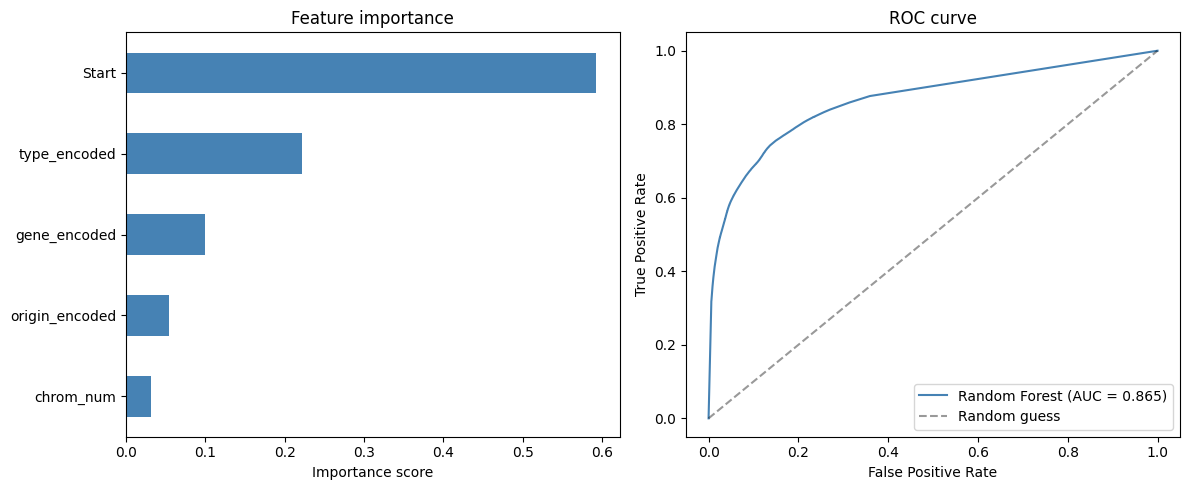

In [8]:
# Cell 14 — figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature importance
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature importance')
axes[0].set_xlabel('Importance score')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue',
             label=f'Random Forest (AUC = {round(roc_auc_score(y_test, y_prob), 3)})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error analysis

We analyse where the model fails to identify systematic
limitations and guide future improvements.

In [9]:
# Cell 16 — gene error rates
df_model['predicted'] = clf.predict(X)
df_model['correct'] = (df_model['predicted'] == df_model['y'])

gene_stats = df_model.groupby('gene_clean').agg(
    total            = ('y', 'count'),
    total_pathogenic = ('y', 'sum'),
    fn = ('y', lambda x: (
        (df_model.loc[x.index, 'y']==1) & 
        (df_model.loc[x.index, 'predicted']==0)
    ).sum()),
    fp = ('y', lambda x: (
        (df_model.loc[x.index, 'y']==0) & 
        (df_model.loc[x.index, 'predicted']==1)
    ).sum()),
)

gene_stats = gene_stats[
    (gene_stats['total'] >= 100) & 
    (gene_stats['total_pathogenic'] >= 20)
]

gene_stats['fn_rate'] = (gene_stats['fn'] / 
    gene_stats['total_pathogenic'].clip(lower=1)).round(3)
gene_stats['fp_rate'] = (gene_stats['fp'] / 
    (gene_stats['total'] - gene_stats['total_pathogenic']).clip(lower=1)).round(3)

print("Highest false negative rate:")
print(gene_stats['fn_rate'].sort_values(ascending=False).head(10))
print("\nHighest false positive rate:")
print(gene_stats['fp_rate'].sort_values(ascending=False).head(10))

Highest false negative rate:
gene_clean
EGLN1     0.533
HCFC1     0.500
COL5A2    0.481
DBH       0.476
RORC      0.458
IDH3A     0.429
MET       0.417
LHX3      0.409
PCSK9     0.405
CA4       0.400
Name: fn_rate, dtype: float64

Highest false positive rate:
gene_clean
GJB1     0.550
IDS      0.528
GBA1     0.518
F9       0.473
PAH      0.466
GLA      0.456
SCN1A    0.423
MPZ      0.400
TYR      0.387
ACTA1    0.380
Name: fp_rate, dtype: float64


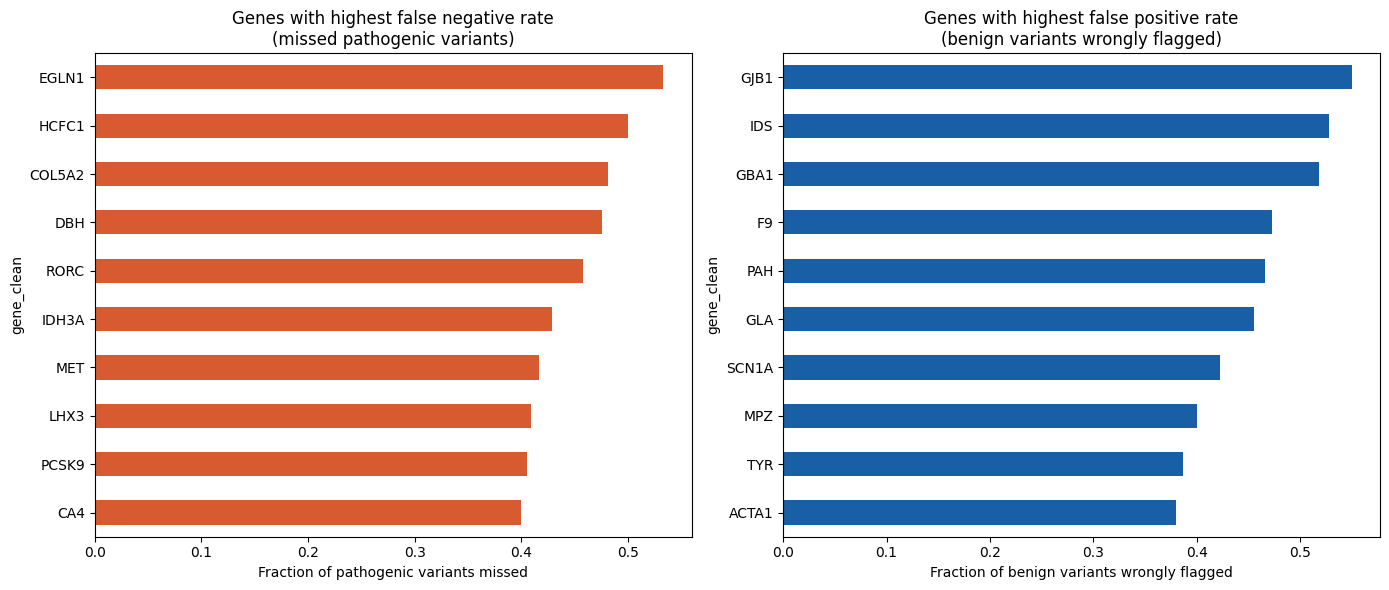

In [10]:
# Cell 17 — error analysis figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_fn = gene_stats['fn_rate'].sort_values(ascending=False).head(10)
top_fn.sort_values().plot(kind='barh', ax=axes[0], color='#D85A30')
axes[0].set_title('Genes with highest false negative rate\n(missed pathogenic variants)')
axes[0].set_xlabel('Fraction of pathogenic variants missed')

top_fp = gene_stats['fp_rate'].sort_values(ascending=False).head(10)
top_fp.sort_values().plot(kind='barh', ax=axes[1], color='#185FA5')
axes[1].set_title('Genes with highest false positive rate\n(benign variants wrongly flagged)')
axes[1].set_xlabel('Fraction of benign variants wrongly flagged')

plt.tight_layout()
plt.savefig('../results/figures/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusions and limitations

**What works well:**
- ROC-AUC of 0.865 using only 5 sequencing-derived features
- Genomic position (Start) is the most informative feature (54%)
- Model correctly classifies 94.5% of variants

**Where the model struggles:**
- SNVs have the highest error rate (5.7%) despite being most common
- Genes like COL5A2 and PCSK9 show >40% false negative rate
- X chromosome has elevated error rate (7.4%)

**Why — biological interpretation:**
Genomic position alone is insufficient for pathogenicity prediction.
Errors concentrate in genes where pathogenicity depends on protein
domain context (COL5A2, PCSK9) or where benign variants cluster
near pathogenic hotspots (SCN1A, GJB1).

**Future work:**
Adding protein domain annotation, evolutionary conservation scores
(PhyloP), and population frequency (gnomAD) would address the
main limitations identified in this error analysis.